## Post Graduation Income data cleaning 

In [17]:
import pandas as pd

In [18]:
# Load the dataset
df = pd.read_csv("../data/raw/postgrad-income/data.zip")

In [19]:
# Inspect the data
print(df.info())
print(f"Initial number of rows: {len(df)}") 

<class 'pandas.DataFrame'>
RangeIndex: 1384926 entries, 0 to 1384925
Data columns (total 21 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   REF_DATE                          1384926 non-null  int64  
 1   GEO                               1384926 non-null  str    
 2   DGUID                             1384926 non-null  str    
 3   Educational qualification         1384926 non-null  str    
 4   Field of study                    1384926 non-null  str    
 5   Gender                            1384926 non-null  str    
 6   Age group                         1384926 non-null  str    
 7   Population group                  1384926 non-null  str    
 8   Characteristics after graduation  1384926 non-null  str    
 9   Graduate statistics               1384926 non-null  str    
 10  UOM                               1384926 non-null  str    
 11  UOM_ID                            1384926 non-nu

In [20]:
# Clean up column names

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1384926 entries, 0 to 1384925
Data columns (total 21 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   ref_date                          1384926 non-null  int64  
 1   geo                               1384926 non-null  str    
 2   dguid                             1384926 non-null  str    
 3   educational_qualification         1384926 non-null  str    
 4   field_of_study                    1384926 non-null  str    
 5   gender                            1384926 non-null  str    
 6   age_group                         1384926 non-null  str    
 7   population_group                  1384926 non-null  str    
 8   characteristics_after_graduation  1384926 non-null  str    
 9   graduate_statistics               1384926 non-null  str    
 10  uom                               1384926 non-null  str    
 11  uom_id                            1384926 non-nu

In [21]:
df["characteristics_after_graduation"].value_counts()


characteristics_after_graduation
Graduates reporting employment income    1384926
Name: count, dtype: int64

In [22]:
df["scalar_factor"].value_counts()

scalar_factor
units    1384926
Name: count, dtype: int64

In [23]:
df["decimals"].value_counts()

decimals
0    1384926
Name: count, dtype: int64

In [24]:
# Remove unnecessary metadata or empty columns

columns_to_drop = ["dguid", "characteristics_after_graduation", "symbol", "terminated", "uom_id", "scalar_factor", "scalar_id", "vector", "coordinate", "decimals", "uom"]
                       
df = df.drop(columns=columns_to_drop)

In [25]:
# Drop rows with suppressed median income values 
df = df[df["status"] != "x"]
df = df.drop(columns="status")
print(f"Number of non-suppressed rows: {len(df)}") 

Number of non-suppressed rows: 1127152


In [26]:
# Rename column names
rename_map = {
    'ref_date': 'year',
    'geo': 'location'
}

# Apply renaming
df = df.rename(columns=rename_map)

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 1127152 entries, 0 to 1384925
Data columns (total 9 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   year                       1127152 non-null  int64  
 1   location                   1127152 non-null  str    
 2   educational_qualification  1127152 non-null  str    
 3   field_of_study             1127152 non-null  str    
 4   gender                     1127152 non-null  str    
 5   age_group                  1127152 non-null  str    
 6   population_group           1127152 non-null  str    
 7   graduate_statistics        1127152 non-null  str    
 8   value                      1127152 non-null  float64
dtypes: float64(1), int64(1), str(7)
memory usage: 86.0 MB


In [28]:
# Pivot data wider to match median income with number of graduates

id_cols = ["year", "location", "educational_qualification", "field_of_study", "gender", "age_group", "population_group", ] 

df_wide = df.pivot_table(
    index=id_cols,
    columns="graduate_statistics",
    values="value",
    aggfunc="first"
).reset_index()

# Keep only rows where 'Median employment income' is available (drops NaNs)
df_filtered = df_wide.dropna(subset=["Median employment income"])

# Rename the created columns cleanly
rename_map = {
    'Median employment income': 'median_income',
    'Number of graduates': 'number_graduates'
}

# Apply renaming
df_filtered = df_filtered.rename(columns=rename_map)

# Drop the created index column
df_filtered.columns.name = None

In [29]:
df_filtered.head()


,year,location,educational_qualification,field_of_study,gender,age_group,population_group,median_income,number_graduates
3,2014,Alberta,"Career, technical or professional training cer...","Agriculture, natural resources and conservatio...",Man,15 to 34 years,Not a visible minority,52800.0,70.0
5,2014,Alberta,"Career, technical or professional training cer...","Agriculture, natural resources and conservatio...",Man,15 to 34 years,"Total, graduates reporting employment income",52800.0,60.0
11,2014,Alberta,"Career, technical or professional training cer...","Agriculture, natural resources and conservatio...",Man,15 to 64 years,Not a visible minority,61000.0,70.0
13,2014,Alberta,"Career, technical or professional training cer...","Agriculture, natural resources and conservatio...",Man,15 to 64 years,"Total, graduates reporting employment income",61000.0,70.0
25,2014,Alberta,"Career, technical or professional training cer...","Agriculture, natural resources and conservatio...","Total, gender",15 to 34 years,Not a visible minority,41300.0,170.0


In [30]:
df_filtered.info()


<class 'pandas.DataFrame'>
Index: 182143 entries, 3 to 944894
Data columns (total 9 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   year                       182143 non-null  int64  
 1   location                   182143 non-null  str    
 2   educational_qualification  182143 non-null  str    
 3   field_of_study             182143 non-null  str    
 4   gender                     182143 non-null  str    
 5   age_group                  182143 non-null  str    
 6   population_group           182143 non-null  str    
 7   median_income              182143 non-null  float64
 8   number_graduates           182143 non-null  float64
dtypes: float64(2), int64(1), str(6)
memory usage: 13.9 MB


In [31]:
# Remove duplicates
df_filtered = df_filtered.drop_duplicates()

In [32]:
# Remove aggregated rows - anything with "Total" in it or the age group 15 to 64 years

total_mask = df_filtered.astype(str).apply(
    lambda col: col.str.contains(r'\bTotal\b', case=False, na=False, regex=True)
).any(axis=1)

# 2. Check specifically for the aggregate age range in 'age_group'
age_mask = df_filtered['age_group'].eq('15 to 64 years') if 'age_group' in df_filtered.columns else False

# Combine both masks using a bitwise OR (|) to drop rows matching either condition
drop_mask = total_mask | age_mask

# Filter out the rows
df_final = df_filtered[~drop_mask].copy()

# Verify how many aggregate rows were removed
print(f"Removed {drop_mask.sum()} aggregate rows.")
print(f"New dataset shape: {df_final.shape}")

Removed 148930 aggregate rows.
New dataset shape: (33213, 9)


In [33]:
# Save cleaned file
df_final.to_csv("../data/clean/postgradincome.csv", index=False)

In [34]:
# Validate cleaned data
clean_data= pd.read_csv("../data/clean/postgradincome.csv")
print(f"Final cleaned dataset rows: {len(clean_data)}")  # Final row count
clean_data.head()

Final cleaned dataset rows: 33213


,year,location,educational_qualification,field_of_study,gender,age_group,population_group,median_income,number_graduates
0,2014,Alberta,"Career, technical or professional training cer...","Agriculture, natural resources and conservatio...",Man,15 to 34 years,Not a visible minority,52800.0,70.0
1,2014,Alberta,"Career, technical or professional training cer...","Agriculture, natural resources and conservatio...",Woman,15 to 34 years,Not a visible minority,36600.0,100.0
2,2014,Alberta,"Career, technical or professional training cer...","Architecture, engineering, and related trades [8]",Man,15 to 34 years,Not a visible minority,72300.0,460.0
3,2014,Alberta,"Career, technical or professional training cer...","Architecture, engineering, and related trades [8]",Man,15 to 34 years,South Asian,60200.0,20.0
4,2014,Alberta,"Career, technical or professional training cer...","Architecture, engineering, and related trades [8]",Man,15 to 34 years,Visible minority population,45500.0,100.0


## EDA below

/var/folders/yt/5xnpd16x4tnd5qbzvz90xrwr0000gn/T/ipykernel_69438/629586615.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_yticklabels(wrap_labels(axes[1, 0].get_yticks() if hasattr(axes[1, 0], 'get_categories') else [t.get_text() for t in axes[1, 0].get_yticklabels()], width=25))
/var/folders/yt/5xnpd16x4tnd5qbzvz90xrwr0000gn/T/ipykernel_69438/629586615.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_yticklabels(wrap_labels([t.get_text() for t in axes[1, 1].get_yticklabels()], width=25))


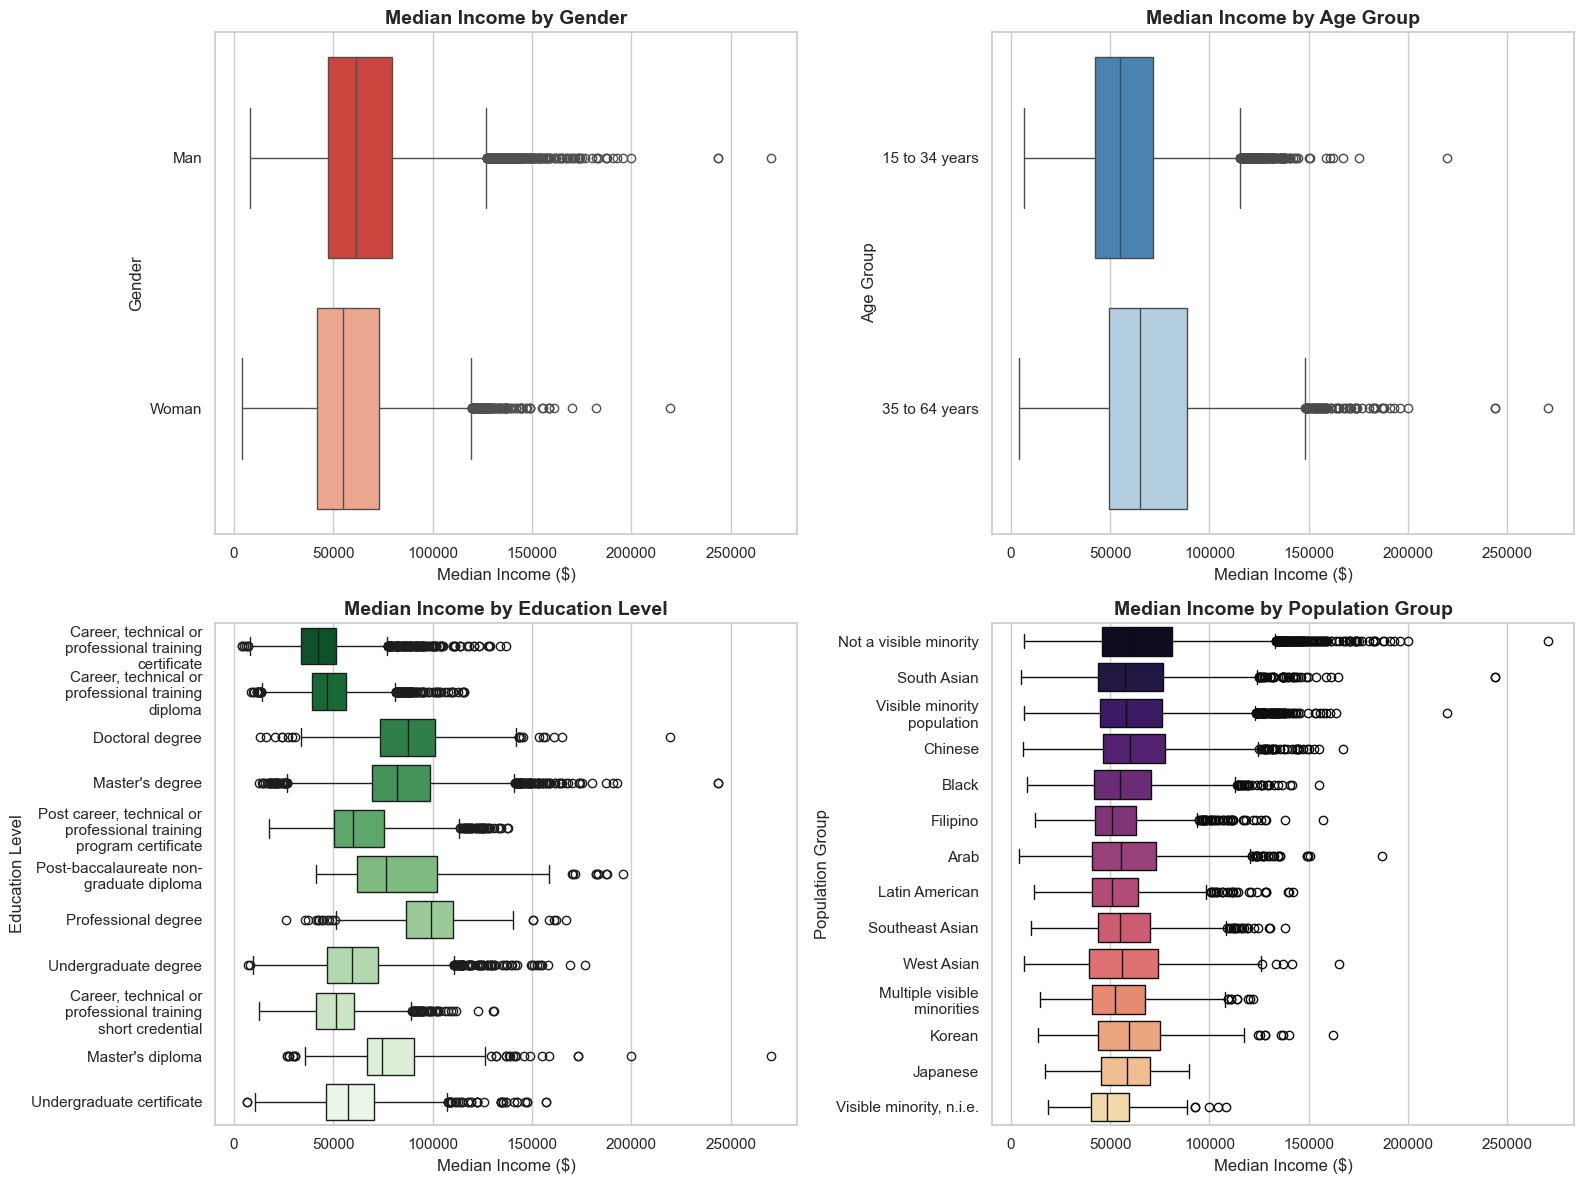

In [35]:
import textwrap
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to wrap long strings
def wrap_labels(labels, width=20):
    return [textwrap.fill(str(label), width=width) for label in labels]

# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Income by Gender
sns.boxplot(
    data=clean_data, x='median_income', y='gender', hue='gender',
    ax=axes[0, 0], palette='Reds_r', legend=False, showcaps=True
)
axes[0, 0].set_title('Median Income by Gender', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Median Income ($)')
axes[0, 0].set_ylabel('Gender')

# 2. Income by Age Group
sns.boxplot(
    data=clean_data, x='median_income', y='age_group', hue='age_group',
    ax=axes[0, 1], palette='Blues_r', legend=False, showcaps=True
)
axes[0, 1].set_title('Median Income by Age Group', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Median Income ($)')
axes[0, 1].set_ylabel('Age Group')

# 3. Income by Educational Qualification (Applying wrap here)
sns.boxplot(
    data=clean_data, x='median_income', y='educational_qualification', hue='educational_qualification',
    ax=axes[1, 0], palette='Greens_r', legend=False, showcaps=True
)
axes[1, 0].set_title('Median Income by Education Level', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Median Income ($)')
axes[1, 0].set_ylabel('Education Level')
# Grab current tick labels, wrap them to ~25 characters, and apply back
axes[1, 0].set_yticklabels(wrap_labels(axes[1, 0].get_yticks() if hasattr(axes[1, 0], 'get_categories') else [t.get_text() for t in axes[1, 0].get_yticklabels()], width=25))

# 4. Income by Population Group (Applying wrap here too)
sns.boxplot(
    data=clean_data, x='median_income', y='population_group', hue='population_group',
    ax=axes[1, 1], palette='magma', legend=False, showcaps=True
)
axes[1, 1].set_title('Median Income by Population Group', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Median Income ($)')
axes[1, 1].set_ylabel('Population Group')
axes[1, 1].set_yticklabels(wrap_labels([t.get_text() for t in axes[1, 1].get_yticklabels()], width=25))

plt.tight_layout()
plt.show()

/var/folders/yt/5xnpd16x4tnd5qbzvz90xrwr0000gn/T/ipykernel_69438/1560820100.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_yticklabels(wrap_labels([t.get_text() for t in axes[1, 0].get_yticklabels()], width=25))
/var/folders/yt/5xnpd16x4tnd5qbzvz90xrwr0000gn/T/ipykernel_69438/1560820100.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_yticklabels(wrap_labels([t.get_text() for t in axes[1, 1].get_yticklabels()], width=25))


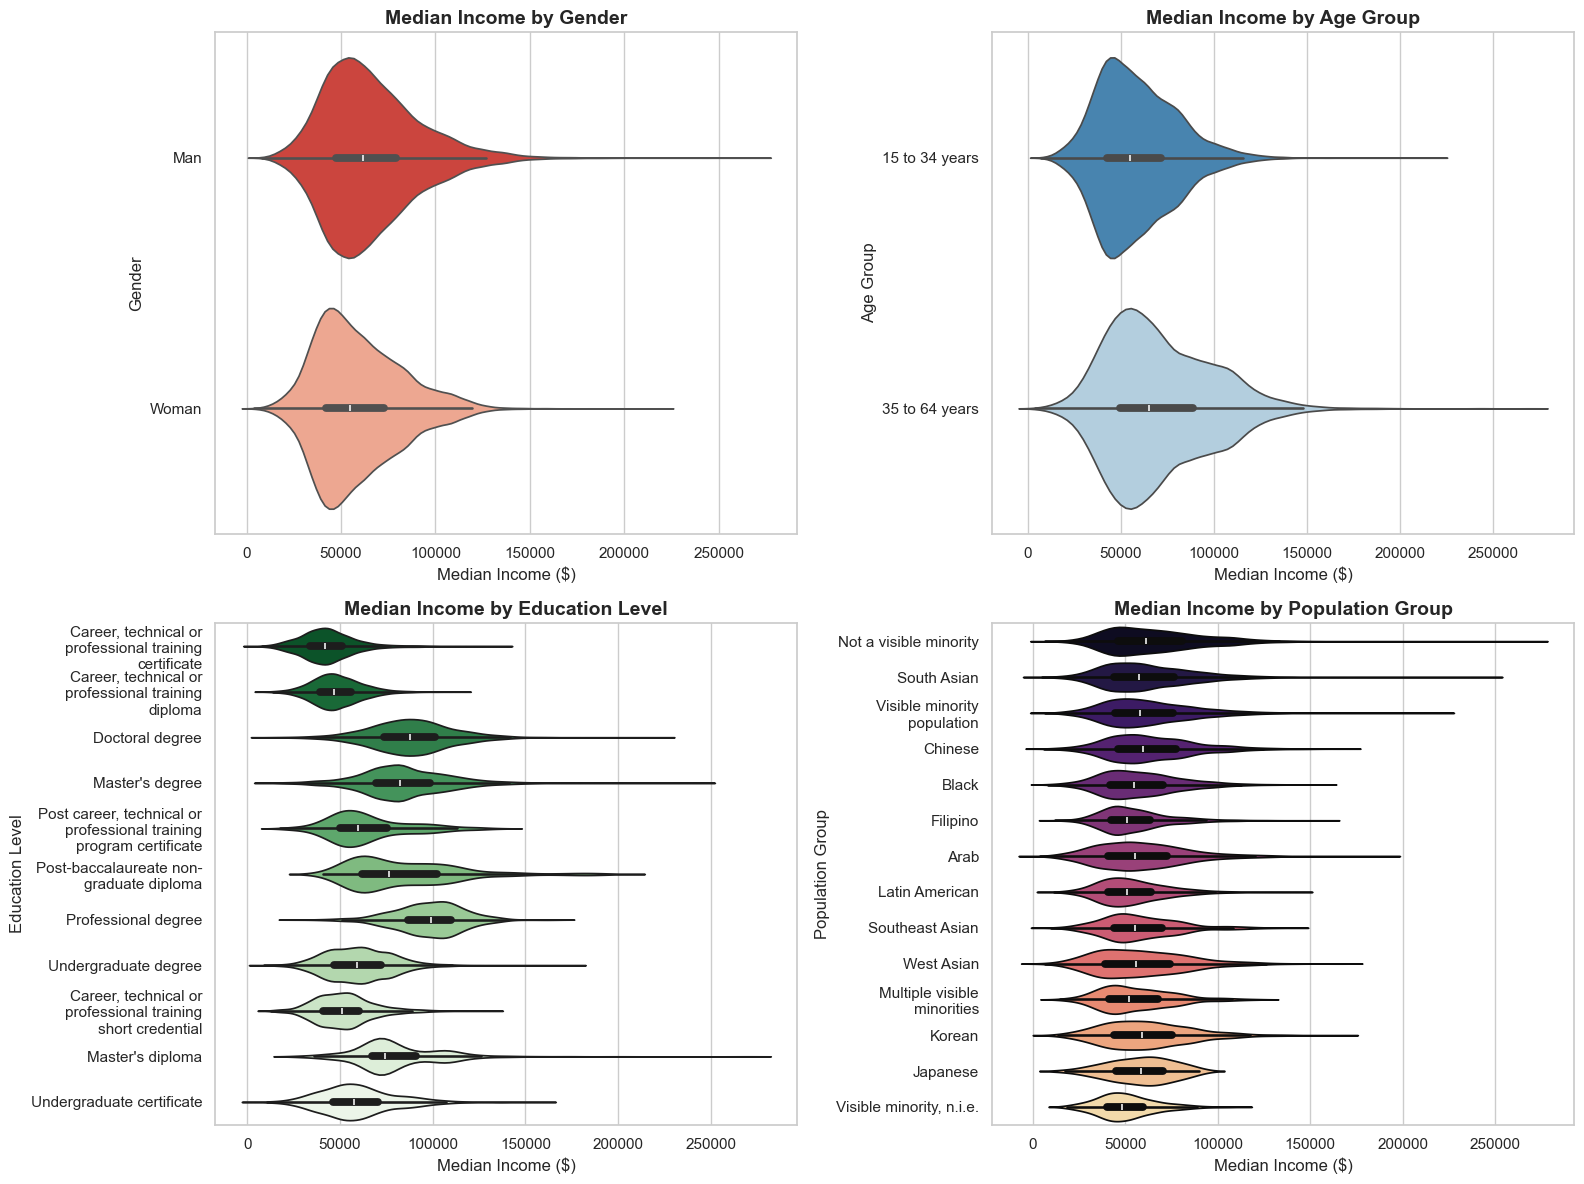

In [36]:
import textwrap
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to wrap long category strings
def wrap_labels(labels, width=25):
    return [textwrap.fill(str(label), width=width) for label in labels]

# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Income by Gender
sns.violinplot(
    data=clean_data, x='median_income', y='gender', hue='gender',
    ax=axes[0, 0], inner='box', palette='Reds_r', legend=False
)
axes[0, 0].set_title('Median Income by Gender', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Median Income ($)')
axes[0, 0].set_ylabel('Gender')

# 2. Income by Age Group
sns.violinplot(
    data=clean_data, x='median_income', y='age_group', hue='age_group',
    ax=axes[0, 1], inner='box', palette='Blues_r', legend=False
)
axes[0, 1].set_title('Median Income by Age Group', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Median Income ($)')
axes[0, 1].set_ylabel('Age Group')

# 3. Income by Educational Qualification (with text wrapping)
sns.violinplot(
    data=clean_data, x='median_income', y='educational_qualification', hue='educational_qualification',
    ax=axes[1, 0], inner='box', palette='Greens_r', legend=False
)
axes[1, 0].set_title('Median Income by Education Level', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Median Income ($)')
axes[1, 0].set_ylabel('Education Level')
axes[1, 0].set_yticklabels(wrap_labels([t.get_text() for t in axes[1, 0].get_yticklabels()], width=25))

# 4. Income by Population Group (with text wrapping)
sns.violinplot(
    data=clean_data, x='median_income', y='population_group', hue='population_group',
    ax=axes[1, 1], inner='box', palette='magma', legend=False
)
axes[1, 1].set_title('Median Income by Population Group', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Median Income ($)')
axes[1, 1].set_ylabel('Population Group')
axes[1, 1].set_yticklabels(wrap_labels([t.get_text() for t in axes[1, 1].get_yticklabels()], width=25))

plt.tight_layout()
plt.show()